In [1]:
import pandas as pd

df = pd.read_csv("../data/police violation_anonymized.csv")

In [2]:
df.head()
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 298450 entries, 0 to 298449
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            298450 non-null  str    
 1   latitude                      298450 non-null  float64
 2   longitude                     298450 non-null  float64
 3   location                      295409 non-null  str    
 4   vehicle_number                298450 non-null  str    
 5   vehicle_type                  298450 non-null  str    
 6   description                   0 non-null       float64
 7   violation_type                298450 non-null  str    
 8   offence_code                  298450 non-null  str    
 9   created_datetime              298450 non-null  str    
 10  closed_datetime               0 non-null       float64
 11  modified_datetime             298450 non-null  str    
 12  device_id                     298450 non-null  str    


(298450, 24)

In [3]:
df.isnull().sum()

id                                   0
latitude                             0
longitude                            0
location                          3041
vehicle_number                       0
vehicle_type                         0
description                     298450
violation_type                       0
offence_code                         0
created_datetime                     0
closed_datetime                 298450
modified_datetime                    0
device_id                            0
created_by_id                        5
center_code                      11260
police_station                       5
data_sent_to_scita                   0
junction_name                        5
action_taken_timestamp          298450
data_sent_to_scita_timestamp    256289
updated_vehicle_number          125254
updated_vehicle_type            125254
validation_status               125254
validation_timestamp            125254
dtype: int64

In [5]:
df['created_datetime'] = pd.to_datetime(df['created_datetime'])

ValueError: time data "2024-03-20 03:30:21.022782+00" doesn't match format "%Y-%m-%d %H:%M:%S%z". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [6]:
df['created_datetime'].dtype

<StringDtype(na_value=nan)>

In [7]:
df['created_datetime'] = pd.to_datetime(
    df['created_datetime'],
    format='mixed'
)

In [8]:
df['created_datetime'].head()

0   2023-11-20 00:28:46+00:00
1   2023-11-24 22:46:46+00:00
2   2023-11-20 00:27:46+00:00
3   2023-11-16 06:47:46+00:00
4   2023-11-22 04:56:46+00:00
Name: created_datetime, dtype: datetime64[us, UTC]

In [9]:
df['created_datetime'] = pd.to_datetime(
    df['created_datetime'],
    format='mixed',
    errors='coerce'
)

In [10]:
df['created_datetime'].isnull().sum()

np.int64(0)

In [11]:
df['hour'] = df['created_datetime'].dt.hour

df['day'] = df['created_datetime'].dt.day_name()

df['month'] = df['created_datetime'].dt.month

In [12]:
df['created_datetime'] = pd.to_datetime(
    df['created_datetime'],
    format='mixed',
    errors='coerce'
)

print(df['created_datetime'].isnull().sum())

0


In [13]:
df['hour'] = df['created_datetime'].dt.hour

df['day'] = df['created_datetime'].dt.day_name()

df['month'] = df['created_datetime'].dt.month

In [14]:
df[['created_datetime','hour','day','month']].head()

,created_datetime,hour,day,month
0,2023-11-20 00:28:46+00:00,0,Monday,11
1,2023-11-24 22:46:46+00:00,22,Friday,11
2,2023-11-20 00:27:46+00:00,0,Monday,11
3,2023-11-16 06:47:46+00:00,6,Thursday,11
4,2023-11-22 04:56:46+00:00,4,Wednesday,11


In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 298450 entries, 0 to 298449
Data columns (total 27 columns):
 #   Column                        Non-Null Count   Dtype              
---  ------                        --------------   -----              
 0   id                            298450 non-null  str                
 1   latitude                      298450 non-null  float64            
 2   longitude                     298450 non-null  float64            
 3   location                      295409 non-null  str                
 4   vehicle_number                298450 non-null  str                
 5   vehicle_type                  298450 non-null  str                
 6   description                   0 non-null       float64            
 7   violation_type                298450 non-null  str                
 8   offence_code                  298450 non-null  str                
 9   created_datetime              298450 non-null  datetime64[us, UTC]
 10  closed_datetime               0

In [16]:
df.columns

Index(['id', 'latitude', 'longitude', 'location', 'vehicle_number',
       'vehicle_type', 'description', 'violation_type', 'offence_code',
       'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id',
       'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita',
       'junction_name', 'action_taken_timestamp',
       'data_sent_to_scita_timestamp', 'updated_vehicle_number',
       'updated_vehicle_type', 'validation_status', 'validation_timestamp',
       'hour', 'day', 'month'],
      dtype='str')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 298450 entries, 0 to 298449
Data columns (total 27 columns):
 #   Column                        Non-Null Count   Dtype              
---  ------                        --------------   -----              
 0   id                            298450 non-null  str                
 1   latitude                      298450 non-null  float64            
 2   longitude                     298450 non-null  float64            
 3   location                      295409 non-null  str                
 4   vehicle_number                298450 non-null  str                
 5   vehicle_type                  298450 non-null  str                
 6   description                   0 non-null       float64            
 7   violation_type                298450 non-null  str                
 8   offence_code                  298450 non-null  str                
 9   created_datetime              298450 non-null  datetime64[us, UTC]
 10  closed_datetime               0

In [18]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

description                     298450
closed_datetime                 298450
action_taken_timestamp          298450
data_sent_to_scita_timestamp    256289
updated_vehicle_type            125254
validation_status               125254
validation_timestamp            125254
updated_vehicle_number          125254
center_code                      11260
location                          3041
created_by_id                        5
police_station                       5
junction_name                        5
dtype: int64

In [19]:
df['validation_status'].value_counts()

validation_status
approved      115400
rejected       49754
created1        7044
processing       678
duplicate        320
Name: count, dtype: int64

In [20]:
df = df[df['validation_status'] == 'approved']

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df['violation_type'].head()

0    ["WRONG PARKING","PARKING NEAR ROAD CROSSING"]
2        ["WRONG PARKING","PARKING IN A MAIN ROAD"]
3                                    ["NO PARKING"]
4                                    ["NO PARKING"]
5                                    ["NO PARKING"]
Name: violation_type, dtype: str

In [24]:
import ast

df['violation_type'] = df['violation_type'].apply(
    lambda x: ast.literal_eval(x)[0]
)

In [25]:
df['vehicle_type'].value_counts()

vehicle_type
CAR                    36833
SCOOTER                35715
MOTOR CYCLE            15096
PASSENGER AUTO         13859
MAXI-CAB                4877
LGV                     3153
GOODS AUTO              1148
MOPED                    763
PRIVATE BUS              568
VAN                      546
TEMPO                    461
LORRY/GOODS VEHICLE      446
HGV                      413
JEEP                     377
OTHERS                   333
BUS (BMTC/KSRTC)         287
SCHOOL VEHICLE           148
TOURIST BUS              105
TANKER                   103
FACTORY BUS               76
MINI LORRY                72
TRACTOR                   21
Name: count, dtype: int64

In [26]:
df['violation_type'].value_counts()

violation_type
WRONG PARKING                                 54057
NO PARKING                                    53675
PARKING IN A MAIN ROAD                         5793
PARKING ON FOOTPATH                             818
DEFECTIVE NUMBER PLATE                          314
PARKING NEAR ROAD CROSSING                      278
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC         228
DOUBLE PARKING                                  121
PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS        45
PARKING OTHER THAN BUS STOP                      29
PARKING OPPOSITE TO ANOTHER PARKED VEHICLE       21
H T V PROHIBITED                                 16
REFUSE TO GO FOR HIRE                             2
OBSTRUCTING DRIVER                                1
DEMANDING EXCESS FARE                             1
FAIL TO USE SAFETY BELTS                          1
Name: count, dtype: int64

In [27]:
df['police_station'].value_counts().head(10)

police_station
Upparpet             15396
Shivajinagar         11021
Malleshwaram          8470
HAL Old Airport       7743
Vijayanagara          6248
City Market           6162
Rajajinagar           4034
Magadi Road           3302
Jeevanbheemanagar     3104
High ground           2544
Name: count, dtype: int64

In [28]:
df[['latitude','longitude']].describe()

,latitude,longitude
count,115400.000000,115400.000000
mean,12.979976,77.598878
std,0.047702,0.049780
min,12.805449,77.442553
25%,12.963910,77.571146
50%,12.977113,77.582340
75%,12.995253,77.615753
max,13.266818,77.771735


In [29]:
df = df[
    (df['latitude'].between(-90,90))
    &
    (df['longitude'].between(-180,180))
]

In [30]:
df.to_csv(
    "../data/cleaned_parking_data.csv",
    index=False
)

In [31]:
df = pd.read_csv(
    "../data/cleaned_parking_data.csv"
)

C:\Users\priya\AppData\Local\Temp\ipykernel_23216\1084111289.py:1: DtypeWarning: Columns (0: data_sent_to_scita_timestamp) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [32]:
df['validation_status'].value_counts()

df.duplicated().sum()

df['vehicle_type'].value_counts()

df['violation_type'].value_counts()

df['police_station'].value_counts().head(10)

df[['latitude','longitude']].describe()

,latitude,longitude
count,115400.000000,115400.000000
mean,12.979976,77.598878
std,0.047702,0.049780
min,12.805449,77.442553
25%,12.963910,77.571146
50%,12.977113,77.582340
75%,12.995253,77.615753
max,13.266818,77.771735


In [33]:
df['validation_status'].value_counts()

df.duplicated().sum()

df['vehicle_type'].value_counts()

df['violation_type'].value_counts()

df['police_station'].value_counts().head(10)

police_station
Upparpet             15396
Shivajinagar         11021
Malleshwaram          8470
HAL Old Airport       7743
Vijayanagara          6248
City Market           6162
Rajajinagar           4034
Magadi Road           3302
Jeevanbheemanagar     3104
High ground           2544
Name: count, dtype: int64

In [34]:
df['violation_type'].value_counts()

violation_type
WRONG PARKING                                 54057
NO PARKING                                    53675
PARKING IN A MAIN ROAD                         5793
PARKING ON FOOTPATH                             818
DEFECTIVE NUMBER PLATE                          314
PARKING NEAR ROAD CROSSING                      278
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC         228
DOUBLE PARKING                                  121
PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS        45
PARKING OTHER THAN BUS STOP                      29
PARKING OPPOSITE TO ANOTHER PARKED VEHICLE       21
H T V PROHIBITED                                 16
REFUSE TO GO FOR HIRE                             2
OBSTRUCTING DRIVER                                1
DEMANDING EXCESS FARE                             1
FAIL TO USE SAFETY BELTS                          1
Name: count, dtype: int64

In [35]:
df['vehicle_type'].value_counts()

vehicle_type
CAR                    36833
SCOOTER                35715
MOTOR CYCLE            15096
PASSENGER AUTO         13859
MAXI-CAB                4877
LGV                     3153
GOODS AUTO              1148
MOPED                    763
PRIVATE BUS              568
VAN                      546
TEMPO                    461
LORRY/GOODS VEHICLE      446
HGV                      413
JEEP                     377
OTHERS                   333
BUS (BMTC/KSRTC)         287
SCHOOL VEHICLE           148
TOURIST BUS              105
TANKER                   103
FACTORY BUS               76
MINI LORRY                72
TRACTOR                   21
Name: count, dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df['validation_status'].value_counts()

validation_status
approved    115400
Name: count, dtype: int64

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [39]:
df = pd.read_csv(
    "../data/cleaned_parking_data.csv"
)

C:\Users\priya\AppData\Local\Temp\ipykernel_23216\1084111289.py:1: DtypeWarning: Columns (0: data_sent_to_scita_timestamp) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


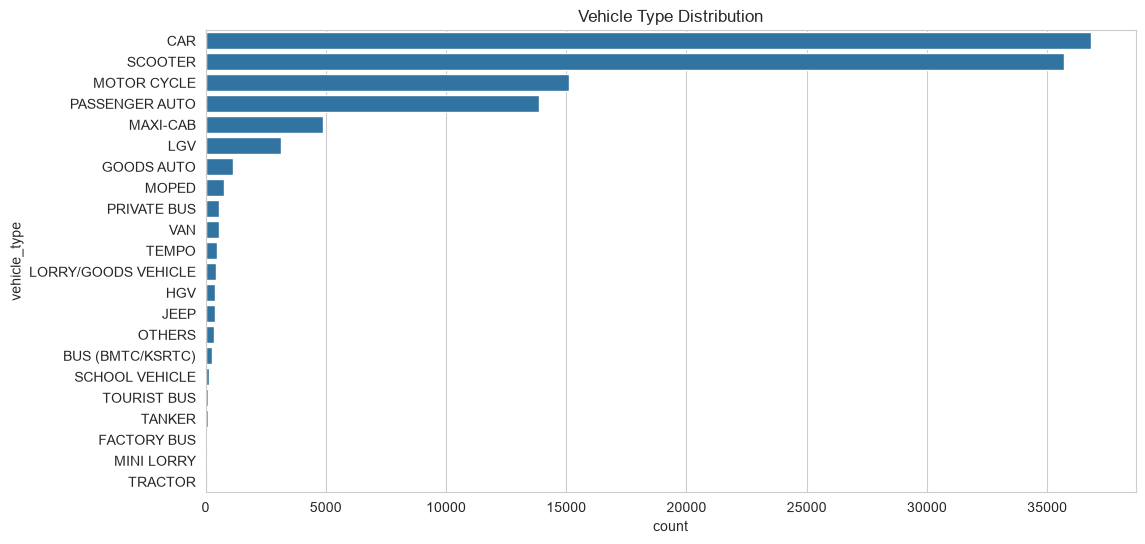

In [40]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='vehicle_type',
    data=df,
    order=df['vehicle_type'].value_counts().index
)

plt.title("Vehicle Type Distribution")
plt.show()

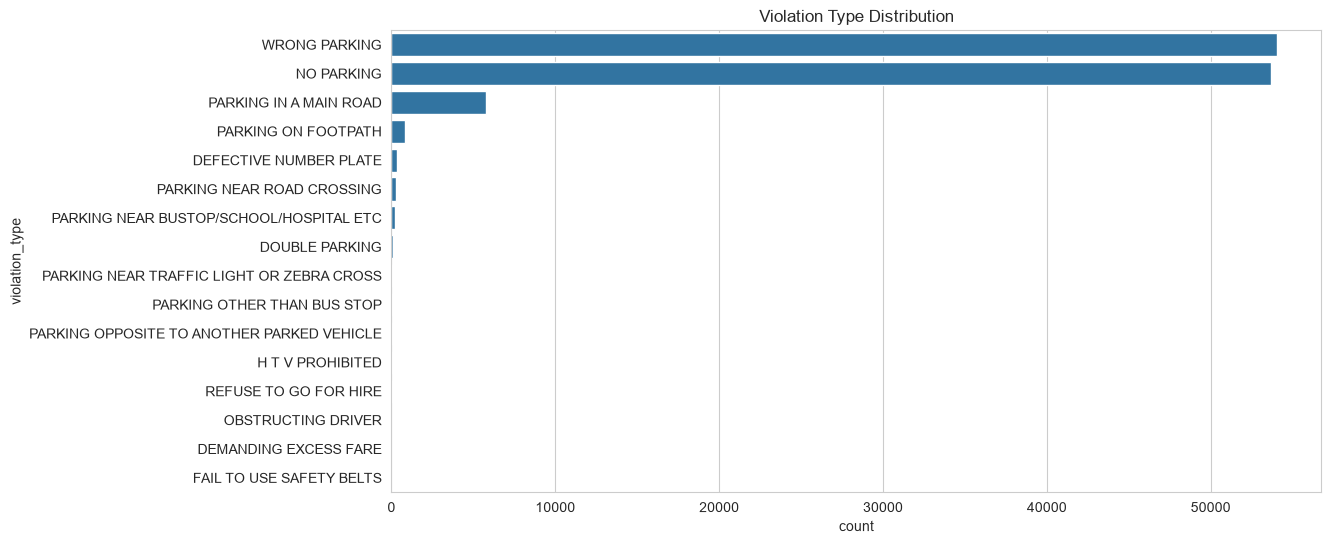

In [41]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='violation_type',
    data=df,
    order=df['violation_type'].value_counts().index
)

plt.title("Violation Type Distribution")
plt.show()

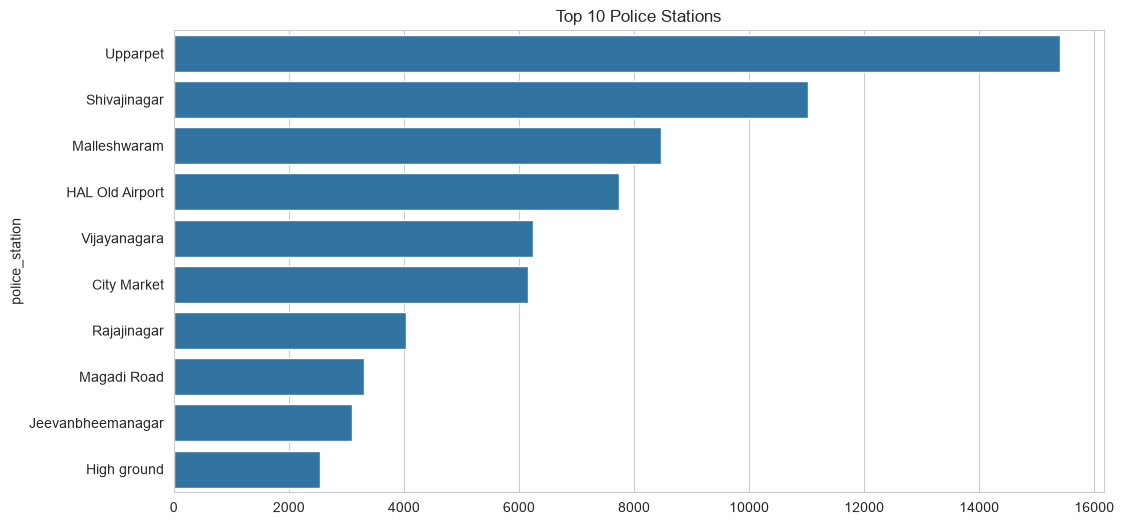

In [42]:
top10 = df['police_station'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Police Stations")
plt.show()

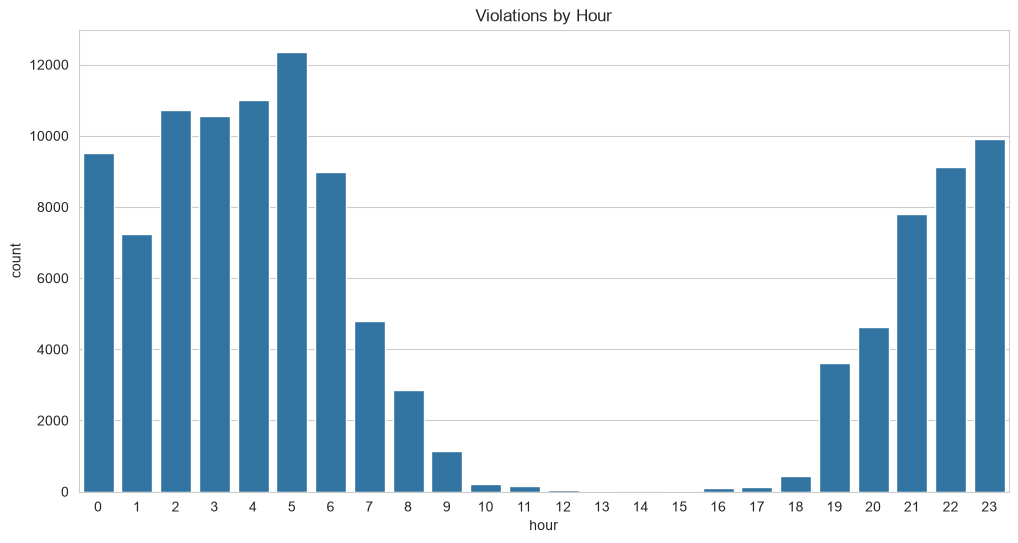

In [43]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='hour',
    data=df
)

plt.title("Violations by Hour")
plt.show()

<Axes: xlabel='hour', ylabel='count'>

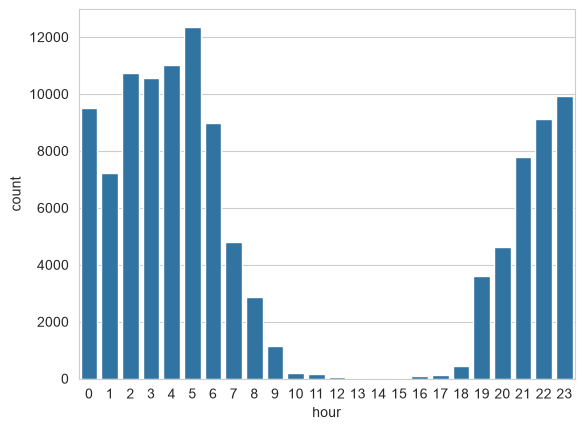

In [44]:
sns.countplot(x='hour', data=df)

In [45]:
df['day'].value_counts()

day
Wednesday    17944
Thursday     17797
Sunday       16901
Friday       16610
Tuesday      16308
Saturday     15844
Monday       13996
Name: count, dtype: int64

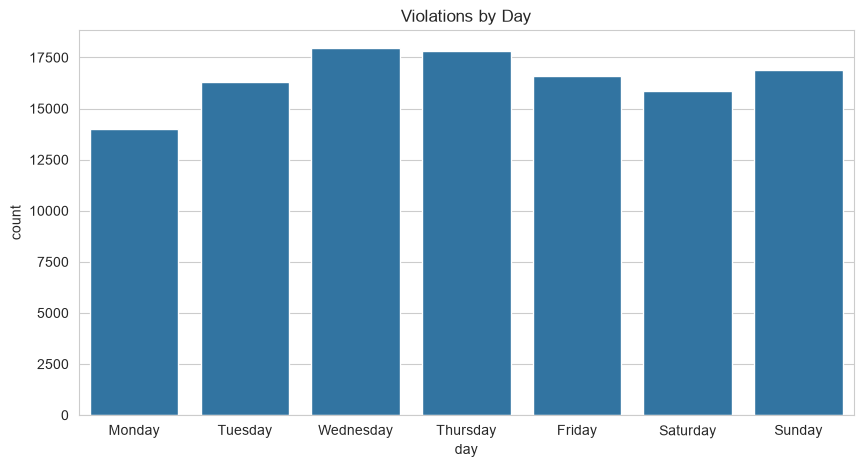

In [46]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='day',
    data=df,
    order=[
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ]
)

plt.title("Violations by Day")
plt.show()